In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt
import os

plt.style.use('seaborn-v0_8-whitegrid')

os.makedirs("project6-backtesting_rebalancing_charts", exist_ok=True)


end_date = dt.date.today()
start_date = end_date - dt.timedelta(days = 5*365)

stocks = ["AAPL", "KO", "^GSPC", "NVDA", "GC=F", "MSFT"]

df = yf.download(stocks, start= start_date, end = end_date)['Close']

df.head(10)

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2021-08-30,149.348816,1809.000000,48.455711,291.363647,22.609795,4528.790039
2021-08-31,148.090576,1815.000000,48.567841,289.722504,22.311769,4522.680176
2021-09-01,148.753830,1813.099976,48.895592,289.674469,22.367588,4524.089844
2021-09-02,149.865768,1808.699951,48.964584,289.021851,22.322741,4536.950195
2021-09-03,150.499756,1830.900024,48.930099,289.012238,22.768278,4535.430176
2021-09-07,152.830902,1795.900024,48.015835,288.090942,22.587866,4520.029785
2021-09-08,151.289810,1790.699951,48.662716,288.119751,22.265923,4514.069824
2021-09-09,150.275436,1797.400024,48.179703,285.278931,22.104456,4493.279785
2021-09-10,145.301025,1789.599976,47.964077,283.800964,22.404472,4458.580078


In [6]:
weight = 1/len(df.columns)
equal_weights = np.full(len(df.columns), weight)
equal_weights

array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [7]:
optimized_weights_df = pd.read_csv("optimized_weights.csv")

optimized_weights = optimized_weights_df["Constrained"].to_numpy()

optimized_weights_df.round(4)

,Asset,Constrained
0,AAPL,0.0551
1,KO,0.2863
2,^GSPC,0.2796
3,NVDA,0.0580
4,GC=F,0.2623
5,MSFT,0.0587


In [8]:
returns = df.pct_change().dropna()
returns.head()

C:\Users\yashr\AppData\Local\Temp\ipykernel_9528\3006030147.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change().dropna()


Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2021-08-31,-0.008425,0.003317,0.002314,-0.005633,-0.013181,-0.001349
2021-09-01,0.004479,-0.001047,0.006748,-0.000166,0.002502,0.000312
2021-09-02,0.007475,-0.002427,0.001411,-0.002253,-0.002005,0.002843
2021-09-03,0.004230,0.012274,-0.000704,-0.000033,0.019959,-0.000335
2021-09-07,0.015489,-0.019116,-0.018685,-0.003188,-0.007924,-0.003396


In [9]:

optimized_return = returns @ optimized_weights

optimized_return.to_csv(
    "optimized_returns.csv",
    index=False
)


equal_return = returns @ equal_weights

equal_return.to_csv(
    "equal_returns.csv",
    index=False
)

benchmark = returns['^GSPC']

In [10]:
strategies = pd.concat([equal_return, optimized_return, benchmark], axis = 1)
strategies.columns = [
    "Equal-Weight Portfolio",
    "Optimized Portfolio",
    "S&P 500"
]

In [11]:
wealth_index = (1 + strategies).cumprod()
wealth_index

,Equal-Weight Portfolio,Optimized Portfolio,S&P 500
Date,,,
2021-08-31,0.996174,0.997269,0.998651
2021-09-01,0.998304,0.999760,0.998962
2021-09-02,0.999143,0.999383,1.001802
2021-09-03,1.005036,1.008141,1.001466
2021-09-07,0.998869,0.995736,0.998066
...,...,...,...
2026-08-24,2.878792,3.652305,1.689824
2026-08-25,2.892387,3.671123,1.695217
2026-08-26,2.882355,3.633584,1.694868


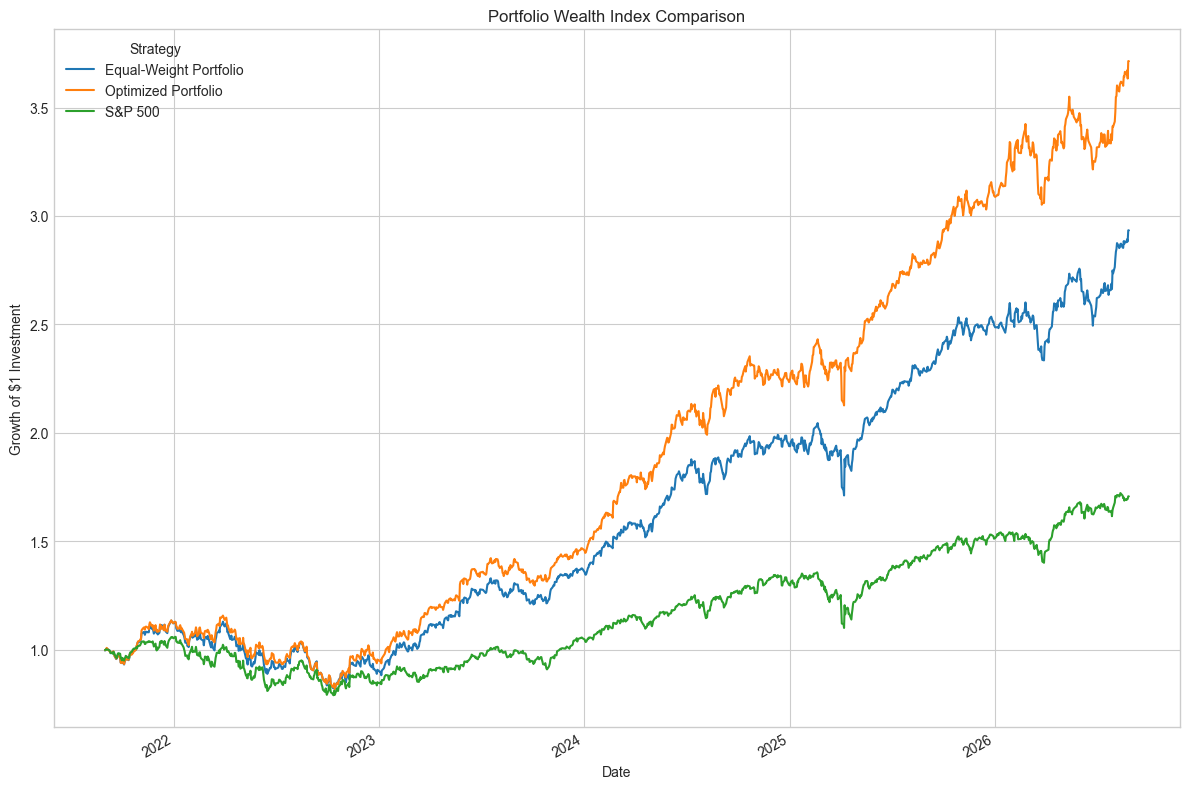

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

wealth_index.plot(ax=ax)

ax.set_title("Portfolio Wealth Index Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1 Investment")
ax.legend(title="Strategy")

plt.tight_layout()
plt.savefig(
    "project6-backtesting_rebalancing_charts/wealth_index_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
rolling_volatilities = strategies.rolling(30).std().dropna()*np.sqrt(252)

In [14]:
def run_backtest(rebalance_frequency):
    rebalancing = returns.copy()
    current_weights = optimized_weights.copy()
    rebalancing_dates = rebalancing.resample(rebalance_frequency).last().index

    daily_returns = []
    for i in range(len(rebalancing)):
        date = rebalancing.index[i]
        current_returns = rebalancing.iloc[i]

        portfolio_return = current_weights @ current_returns
        daily_returns.append(portfolio_return)
        current_weights = current_weights * (1 + current_returns)
        current_weights = current_weights / current_weights.sum()       

        if date in rebalancing_dates:
            current_weights = optimized_weights.copy()

    return pd.Series(
        daily_returns,
        index=rebalancing.index,
        name=f"{rebalance_frequency} Rebalanced Portfolio"
    )

In [15]:
years = len(returns) / 252
def calculate_metrics(portfolio_returns):
    wealth = (1 + portfolio_returns).cumprod()
    volatility = portfolio_returns.rolling(30).std() * np.sqrt(252)
    cagr = wealth.iloc[-1] ** (1 / years) - 1
    sharpe = portfolio_returns.rolling(30).mean() * 252 / volatility
    drawdowns = (wealth - wealth.cummax()) / wealth.cummax()

    return wealth, volatility, cagr, sharpe, drawdowns

In [16]:
monthly_rebalanced_returns  = run_backtest('M')

(
    monthly_rebalanced_wealth, 
    monthly_rebalanced_volatility,
    monthly_rebalanced_cagr,
    monthly_rebalanced_sharpe,
    monthly_rebalanced_drawdowns,
) = calculate_metrics(monthly_rebalanced_returns)

C:\Users\yashr\AppData\Local\Temp\ipykernel_9528\2175570747.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebalancing_dates = rebalancing.resample(rebalance_frequency).last().index


In [17]:
quarterly_rebalanced_returns = run_backtest('Q')

(
    quarterly_rebalanced_wealth, 
    quarterly_rebalanced_volatility,
    quarterly_rebalanced_cagr,
    quarterly_rebalanced_sharpe,
    quarterly_rebalanced_drawdowns,
) = calculate_metrics(quarterly_rebalanced_returns)

C:\Users\yashr\AppData\Local\Temp\ipykernel_9528\2175570747.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  rebalancing_dates = rebalancing.resample(rebalance_frequency).last().index


In [18]:
wealth_comparison = pd.concat([wealth_index, monthly_rebalanced_wealth, quarterly_rebalanced_wealth], axis = 1)
wealth_comparison.round(4).tail()

,Equal-Weight Portfolio,Optimized Portfolio,S&P 500,M Rebalanced Portfolio,Q Rebalanced Portfolio
Date,,,,,
2026-08-24,2.8788,3.6523,1.6898,3.5765,3.8894
2026-08-25,2.8924,3.6711,1.6952,3.5943,3.9082
2026-08-26,2.8824,3.6336,1.6949,3.5575,3.8690
2026-08-27,2.9337,3.7139,1.7071,3.6350,3.9503
2026-08-28,2.9337,3.7139,1.7071,3.6350,3.9503


In [19]:
rolling_sharpes = strategies.rolling(30).mean() * 252 / rolling_volatilities

sharpe_comparison = pd.concat([
    rolling_sharpes,
    monthly_rebalanced_sharpe.rename("Monthly Rebalanced"),
    quarterly_rebalanced_sharpe.rename("Quarterly Rebalanced")
], axis=1)


final_wealth = wealth_index.iloc[-1]
cagr = final_wealth ** (1 / years) - 1

drawdowns = (wealth_index - wealth_index.cummax()) / wealth_index.cummax()

In [20]:
summary = pd.DataFrame({

    "Final Wealth ($1)": [
        wealth_index["S&P 500"].iloc[-1],
        wealth_index["Equal-Weight Portfolio"].iloc[-1],
        wealth_index["Optimized Portfolio"].iloc[-1],
        monthly_rebalanced_wealth.iloc[-1],
        quarterly_rebalanced_wealth.iloc[-1]
    ],

    "CAGR (%)": [
        cagr["S&P 500"] * 100,
        cagr["Equal-Weight Portfolio"] * 100,
        cagr["Optimized Portfolio"] * 100,
        monthly_rebalanced_cagr * 100,
        quarterly_rebalanced_cagr * 100
    ],

    "Annualized Volatility (%)": [
        rolling_volatilities["S&P 500"].mean() * 100,
        rolling_volatilities["Equal-Weight Portfolio"].mean() * 100,
        rolling_volatilities["Optimized Portfolio"].mean() * 100,
        monthly_rebalanced_volatility.mean() * 100,
        quarterly_rebalanced_volatility.mean() * 100
    ],

    "Sharpe Ratio": [
        rolling_sharpes["S&P 500"].mean(),
        rolling_sharpes["Equal-Weight Portfolio"].mean(),
        rolling_sharpes["Optimized Portfolio"].mean(),
        monthly_rebalanced_sharpe.mean(),
        quarterly_rebalanced_sharpe.mean()
    ],

    "Max Drawdown (%)": [
        drawdowns["S&P 500"].min() * 100,
        drawdowns["Equal-Weight Portfolio"].min() * 100,
        drawdowns["Optimized Portfolio"].min() * 100,
        monthly_rebalanced_drawdowns.min() * 100,
        quarterly_rebalanced_drawdowns.min() * 100
    ]

},
index=[
    "S&P 500",
    "Equal-Weight",
    "Optimized",
    "Monthly Rebalanced",
    "Quarterly Rebalanced"
])

summary = summary.round({
    "Final Wealth ($1)": 2,
    "CAGR (%)": 2,
    "Annualized Volatility (%)": 2,
    "Sharpe Ratio": 3,
    "Max Drawdown (%)": 2
})


                      Final Wealth ($1)  CAGR (%)  Annualized Volatility (%)  \
S&P 500                            1.71     11.33                      15.79   
Equal-Weight                       2.93     24.10                      17.35   
Optimized                          3.71     30.12                      17.22   
Monthly Rebalanced                 3.64     29.56                      17.30   
Quarterly Rebalanced               3.95     31.74                      18.68   

                      Sharpe Ratio  Max Drawdown (%)  
S&P 500                      1.356            -25.43  
Equal-Weight                 1.893            -27.87  
Optimized                    2.073            -29.24  
Monthly Rebalanced           1.985            -29.48  
Quarterly Rebalanced         1.894            -28.57  


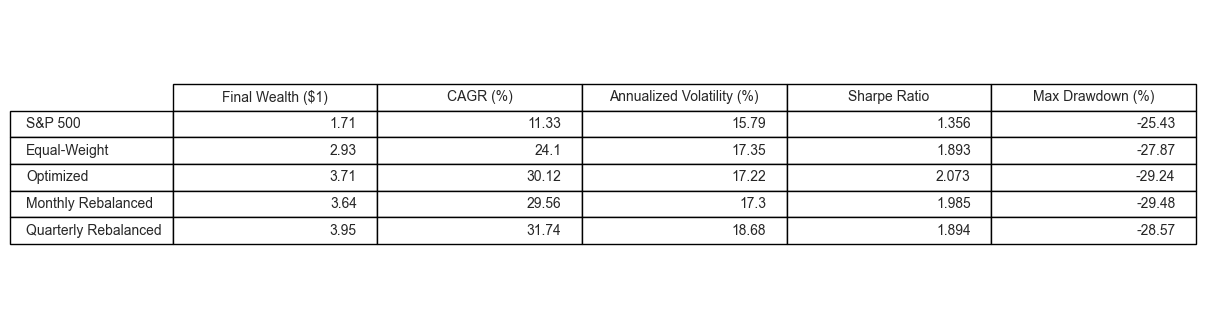

In [21]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")

table = ax.table(
    cellText=summary.values,
    rowLabels=summary.index,
    colLabels=summary.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

plt.savefig(
    "project6-backtesting_rebalancing_charts/performance_summary.png",
    dpi=300,
    bbox_inches="tight"
)

summary.to_csv(
"project6-backtesting_rebalancing_charts/performance_summary.csv"
)

print(summary)



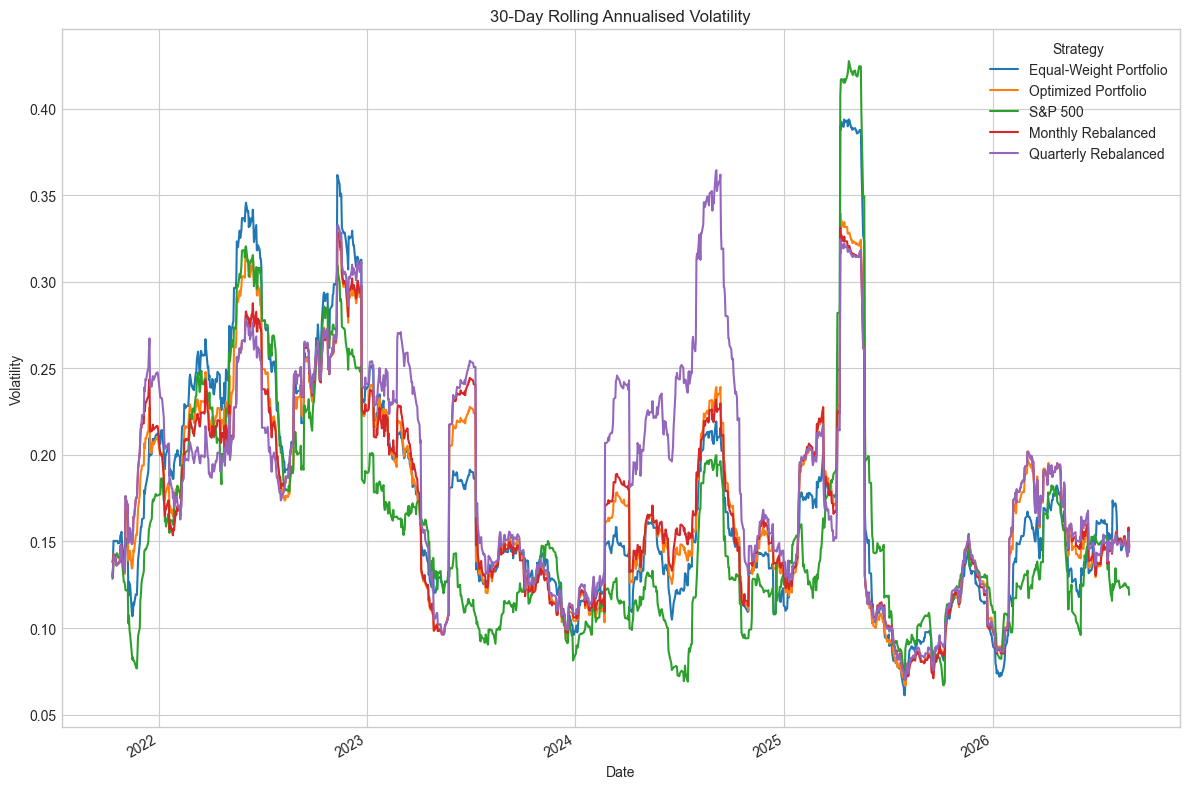

In [22]:
fig, ax = plt.subplots(figsize=(12, 8))

volatility_comparison = pd.concat([
    rolling_volatilities,
    monthly_rebalanced_volatility.rename("Monthly Rebalanced"),
    quarterly_rebalanced_volatility.rename("Quarterly Rebalanced")
], axis=1)

volatility_comparison.plot(ax=ax)

ax.set_title("30-Day Rolling Annualised Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility")
ax.legend(title="Strategy")

plt.tight_layout()
plt.savefig(
    "project6-backtesting_rebalancing_charts/volatility_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

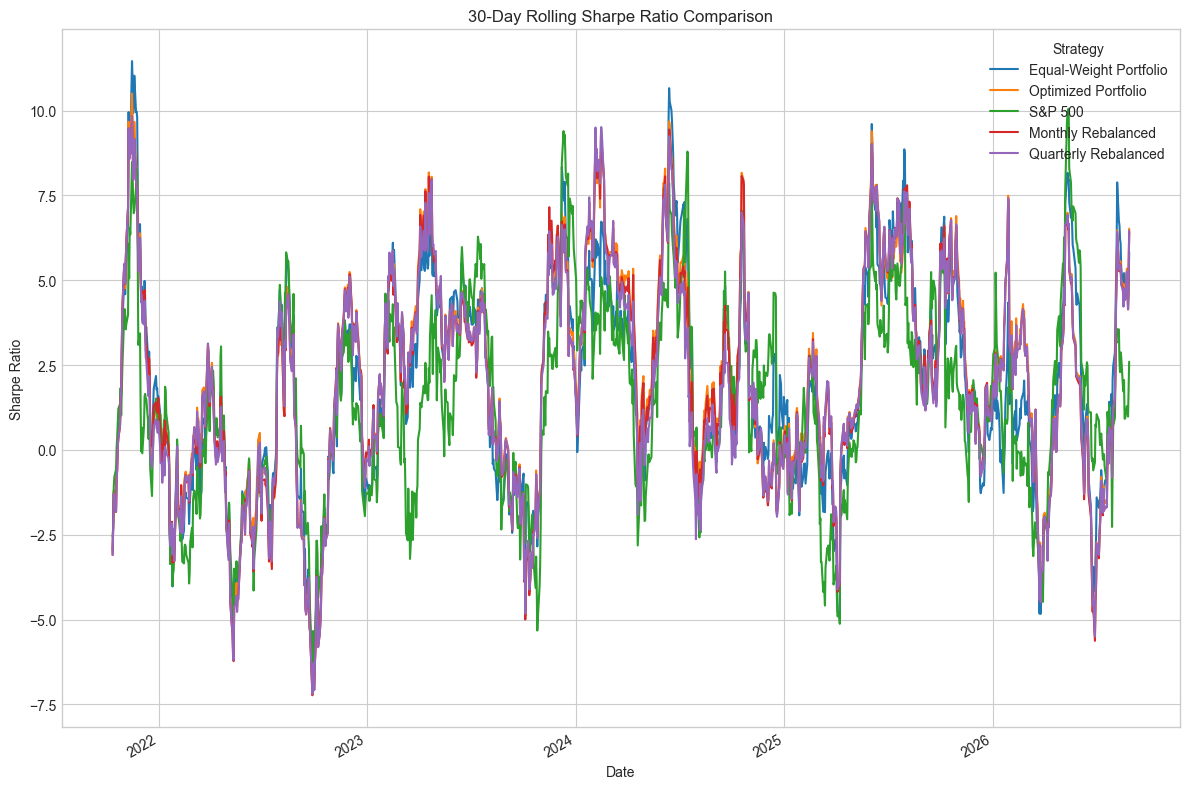

In [23]:
fig, ax = plt.subplots(figsize=(12, 8))

sharpe_comparison.plot(ax=ax)

ax.set_title("30-Day Rolling Sharpe Ratio Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Sharpe Ratio")
ax.legend(title="Strategy")

plt.tight_layout()
plt.savefig(
    "project6-backtesting_rebalancing_charts/sharpe_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

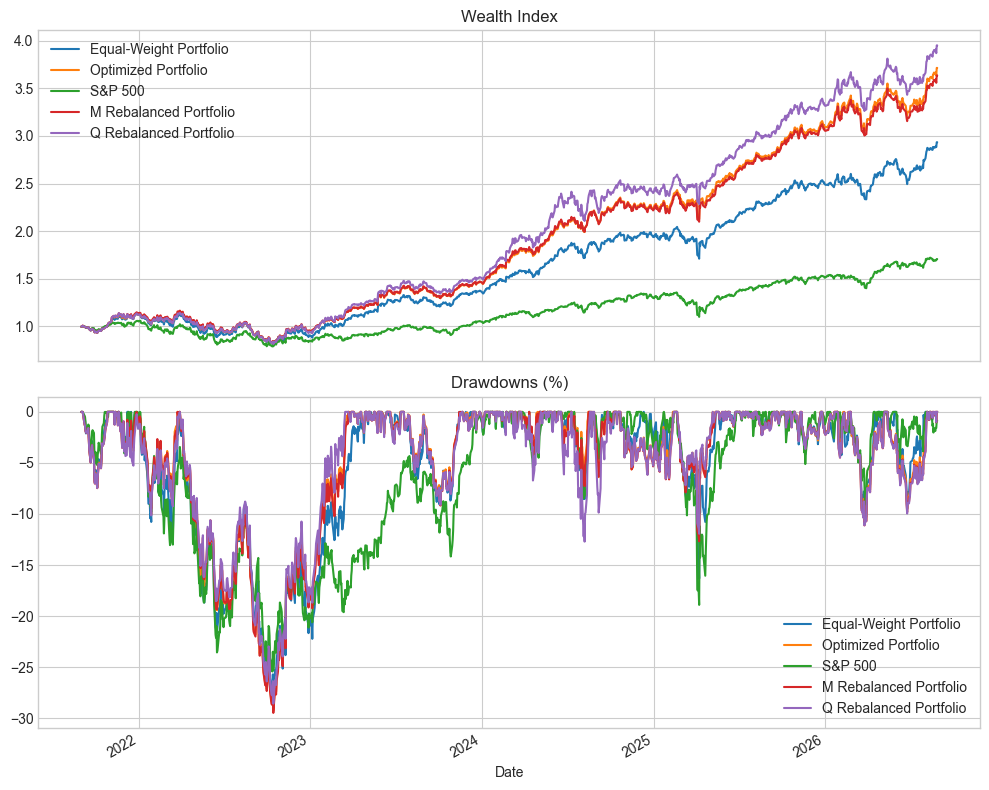

In [24]:
peaks = wealth_comparison.cummax()
comparison_drawdowns = (wealth_comparison - peaks)/peaks
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8),sharex = True)
wealth_comparison.plot(ax=ax1)
ax1.set_title("Wealth Index")
(comparison_drawdowns*100).plot(ax=ax2)
ax2.set_title("Drawdowns (%)")

plt.tight_layout()
plt.savefig("project6-backtesting_rebalancing_charts/wealthindex_drawdowns.png")
plt.show()